# Project Stat 451 Spotify Hits, Group 17

- Alex Wong (acwong7@wisc.edu)
- Aradhya Gupta (asgupta5@wisc.edu)
- Bobby Bui (hhbui2@wisc.edu)
- Mia Patil(mpatil4@wisc.edu)
- Xinwei Chen(xchen2372@wisc.edu)

notes from proposal meeting
- Need to share the feature importance for creating the hits > and coefs or metrics
- LASSO in L1 for logistic regression in sklearn, as you dial the c up, strengthens the regularization
- Doesn’t recommend logistic regression coefs interpretation at all
- Suggesting showing if low danceability has low hits and high danceability has high hits
- 3 graphs > 5 pgs
- Focus on using ml to predict rather to compare between models
- Just pick one to present on after evaluating
- Show the proportion of predictions where y is 1 in addition to accuracy
- Create confusion matrix (Tell something about the errors)


## Import Statements

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import mixture

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import svm, linear_model, datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             accuracy_score, roc_auc_score, RocCurveDisplay)

from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import RandomOverSampler

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             accuracy_score, roc_auc_score, roc_curve, RocCurveDisplay)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report

## Reading in Data

In [2]:
df = pd.read_csv("dataset-of-10s.csv")
df

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
0,Wild Things,Alessia Cara,spotify:track:2ZyuwVvV6Z3XJaXIFbspeE,0.741,0.626,1,-4.826,0,0.0886,0.02000,0.000000,0.0828,0.7060,108.029,188493,4,41.18681,10,1
1,Surfboard,Esquivel!,spotify:track:61APOtq25SCMuK0V5w2Kgp,0.447,0.247,5,-14.661,0,0.0346,0.87100,0.814000,0.0946,0.2500,155.489,176880,3,33.18083,9,0
2,Love Someone,Lukas Graham,spotify:track:2JqnpexlO9dmvjUMCaLCLJ,0.550,0.415,9,-6.557,0,0.0520,0.16100,0.000000,0.1080,0.2740,172.065,205463,4,44.89147,9,1
3,Music To My Ears (feat. Tory Lanez),Keys N Krates,spotify:track:0cjfLhk8WJ3etPTCseKXtk,0.502,0.648,0,-5.698,0,0.0527,0.00513,0.000000,0.2040,0.2910,91.837,193043,4,29.52521,7,0
4,Juju On That Beat (TZ Anthem),Zay Hilfigerrr & Zayion McCall,spotify:track:1lItf5ZXJc1by9SbPeljFd,0.807,0.887,1,-3.892,1,0.2750,0.00381,0.000000,0.3910,0.7800,160.517,144244,4,24.99199,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6393,Lotus Flowers,Yolta,spotify:track:4t1TljQWJ6ZuoSY67zVvBI,0.172,0.358,9,-14.430,1,0.0342,0.88600,0.966000,0.3140,0.0361,72.272,150857,4,24.30824,7,0
6394,Calling My Spirit,Kodak Black,spotify:track:2MShy1GSSgbmGUxADNIao5,0.910,0.366,1,-9.954,1,0.0941,0.09960,0.000000,0.2610,0.7400,119.985,152000,4,32.53856,8,1
6395,Teenage Dream,Katy Perry,spotify:track:55qBw1900pZKfXJ6Q9A2Lc,0.719,0.804,10,-4.581,1,0.0355,0.01320,0.000003,0.1390,0.6050,119.999,227760,4,20.73371,7,1
6396,Stormy Weather,Oscar Peterson,spotify:track:4o9npmYHrOF1rUxxTVH8h4,0.600,0.177,7,-16.070,1,0.0561,0.98900,0.868000,0.1490,0.5600,120.030,213387,4,21.65301,14,0


In [3]:
df.columns

Index(['track', 'artist', 'uri', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'chorus_hit',
       'sections', 'target'],
      dtype='object')

In [4]:
df['tempo'].min()

39.369

In [5]:
df['tempo'].max()

210.977

In [6]:
df['tempo'].median()

121.07

In [7]:
df['loudness'].min()

-46.655

In [8]:
df['loudness'].max()

-0.149

## Data Preprocessing

1. Clean and preprocess the data by removing missing values, normalizing numerical features, and encoding categorical variables (e.g., key, mode).
2. Split the data into training (70%) and testing (30%) sets.


No Categorical Encoding or Numerical Normalization Needed
- danceability: How suitable a track is for dancing (0–1). Higher = more rhythmically, regular and danceable
- energy: (0-1) How loud, fast, and noisy the song is. Higher = more energetic, loud, fast-paced.
- liveness:  Probability that the track was performed to a live audience (0–1)


Categorical Encoding or Numerical Normalization Needed
 - tempo_scaled: used standardscalar. Speed of the track in beats per minute (BPM). Previously, the min tempo in df was 39.369 and max was 210.977
 - loudness_scaled: used standardscalar. Overall loudness in decibels (dB), typically between -60 and 0.
 - chorus_proportion: Estimated timestamp (in seconds) where the chorus begins/total length of song

In [9]:
df['duration_sec'] = df['duration_ms'] / 1000

In [10]:
#from 05 FeatureEngineering notes (calculating a z-score for each value)
scaler = StandardScaler()
df['tempo_scaled'] = scaler.fit_transform(df[['tempo']])
df['loudness_scaled'] = scaler.fit_transform(df[['loudness']])
#the proportion of the song that heard before the chorus hits
df['chorus_proportion'] = df['chorus_hit'] / df['duration_sec']

## Data Cleaning

target: The target variable for the track. It can be either '0' or '1'. '1' implies that this song has featured in the weekly list (Issued by Billboards) of Hot-100 tracks in that decade at least once and is therefore a 'hit'. '0' Implies that the track is a 'flop'.

      The author's condition of a track being 'flop' is as follows:

        - The track must not appear in the 'hit' list of that decade.
        - The track's artist must not appear in the 'hit' list of that decade.
        - The tracak must belong to a genre that could be considered non-mainstream and / or avant-garde. 
        - The track's genre must not have a song in the 'hit' list.
        - The track must have 'US' as one of its markets.


In [11]:
#feature selection
cols_of_interest = ['danceability', 'energy', 'liveness', 'loudness_scaled','tempo_scaled','chorus_proportion']

#creating a function that takes each column of interest and runs it in spotify dataframe, checking for any missing values. if there is a missing value, we remove the whole row and report the number of removed rows per column. 
def drop_missing_and_report(df, cols):
    removed_counts = {}

    for col in cols:
        missing_before = df[col].isna().sum()

        if missing_before > 0:
            df = df.dropna(subset=[col])
        
        removed_counts[col] = missing_before

    return df, removed_counts

spotify_clean, removal_report = drop_missing_and_report(df, cols_of_interest)

removal_report
#no missing data found...

{'danceability': np.int64(0),
 'energy': np.int64(0),
 'liveness': np.int64(0),
 'loudness_scaled': np.int64(0),
 'tempo_scaled': np.int64(0),
 'chorus_proportion': np.int64(0)}

## Train/Test Split - 80% training, 20% validation and testing

In [12]:
from sklearn.model_selection import train_test_split

X = df[cols_of_interest]  # use only the columns you care about
y = df['target']          # target column

# split 80% training data, 20% "_tmp" for validation & test
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=.2,
                                                  random_state=0, stratify=y)
# of remaining 20%, split in half to get 10% validation, 10% test
X_valid, X_test, y_valid, y_test = train_test_split(X_tmp, y_tmp, test_size=.5,
  random_state=0, stratify=y_tmp)



print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_valid.shape, y_valid.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (5118, 6) (5118,)
Validation: (640, 6) (640,)
Test: (640, 6) (640,)


## Model Selection and Training

3. Train and compare multiple classification algorithms:
- Logistic Regression (baseline, interpretable)
- Decision Tree
- KNN

4. Evaluate models using accuracy, F1 score, and ROC-AUC.
5. Interpret model outputs via feature importances and logistic coefficients to determine
which audio features best predict hits.

In [13]:
# Make a list of the four classifiers without setting any hyperparameters.
models = [
    SVC(),
    LogisticRegression(max_iter=5000, solver='liblinear'),#regular logistic regression
    LogisticRegression(max_iter=5000, solver='liblinear', penalty='l1'),#lasso logistic regression
    DecisionTreeClassifier(criterion='entropy'),
    KNeighborsClassifier(),
    RandomForestClassifier()
]
#testing hyperparameters
# Make a list of four corresponding parameter dictionaries. 
param_dict = [
    {"kernel": ["linear", "rbf"], "C": [0.01, 1, 100]},     
    {"C": [0.01, 1, 100]},    
    {"C": [0.001, 0.01, 0.1, 1]},
    {"max_depth": [1, 3, 5, 7]},                            
    {"n_neighbors": [1, 2, 3, 4]},
    {"n_estimators": [50, 100, 200], "max_depth": [None, 5, 10], "min_samples_split": [2, 5]}
    
]

# Initialize best model trackers
best_i = -1
best_acc = -np.inf
best_clf = None

# Loop through models
for i, (model, params) in enumerate(zip(models, param_dict)):
    print(f"Model {i+1}:")
    
    # Grid search with cross-validation
    clf = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=5,
        n_jobs=-1,
        verbose=0
    )
    
    # Fit the model
    clf.fit(X_train, y_train)
    
    # Accuracy on validation set
    val_acc = clf.score(X_valid, y_valid)
    
    # Proportion of predictions where y_pred = 1
    y_pred = clf.predict(X_valid)
    prop_ones = (y_pred == 1).mean()
    
    print(f"Validation accuracy: {val_acc:.4f}")
    print(f"Proportion of predictions where y=1: {prop_ones:.4f}")
    print(f"Best hyperparameters: {clf.best_params_}\n")
    
    # Track the best model
    if val_acc > best_acc:
        best_acc = val_acc
        best_i = i
        best_clf = clf

print(f"The model with best classifier: {best_i+1}")
print(f"The best accuracy score on validation data: {best_acc:.3f}")
print(f"The best classifier with its hyperparameter settings: {best_clf.best_params_}")



Model 1:
Validation accuracy: 0.7625
Proportion of predictions where y=1: 0.5781
Best hyperparameters: {'C': 1, 'kernel': 'rbf'}

Model 2:
Validation accuracy: 0.7484
Proportion of predictions where y=1: 0.5484
Best hyperparameters: {'C': 1}

Model 3:
Validation accuracy: 0.7469
Proportion of predictions where y=1: 0.5500
Best hyperparameters: {'C': 1}

Model 4:
Validation accuracy: 0.7594
Proportion of predictions where y=1: 0.6250
Best hyperparameters: {'max_depth': 5}

Model 5:
Validation accuracy: 0.7141
Proportion of predictions where y=1: 0.5578
Best hyperparameters: {'n_neighbors': 3}

Model 6:
Validation accuracy: 0.7781
Proportion of predictions where y=1: 0.5594
Best hyperparameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}

The model with best classifier: 6
The best accuracy score on validation data: 0.778
The best classifier with its hyperparameter settings: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [14]:
print(f"The best model is (highest accuracy on validation data is:")
best_clf

The best model is (highest accuracy on validation data is:


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]})

Based on validation accuracy, the best model from running the above code is RandomForest (Validation accuracy: 0.772)
The proportion of predictions where y=1 in RandomForest is 0.5656 which is good. (It is not achieving a high accuracy by just setting everything to 1 (unbalanced))

## Feature Importance

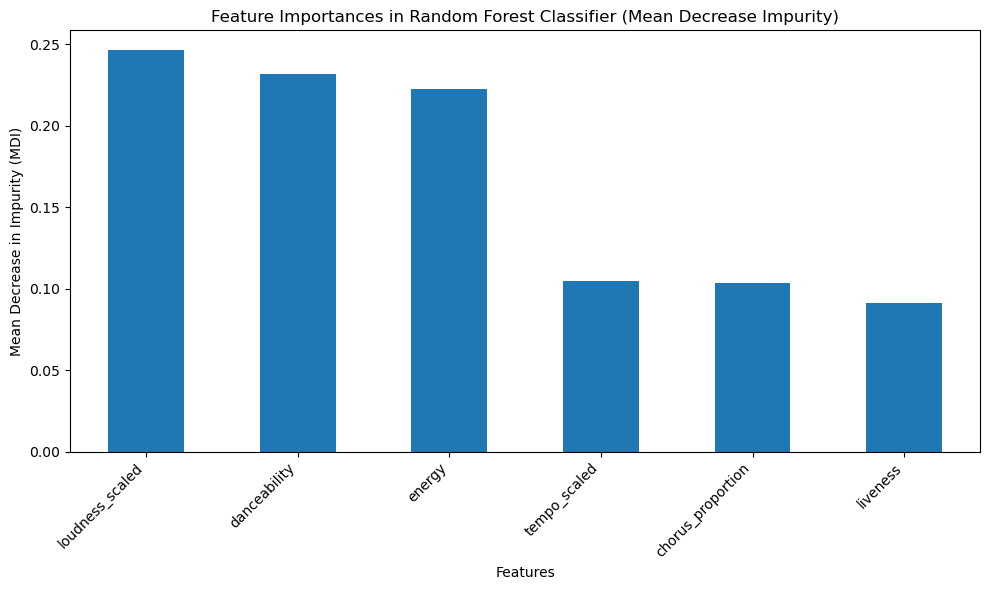

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Access the best estimator from the GridSearchCV object
# This is the actual RandomForestClassifier that has the feature_importances_ attribute
best_estimator = best_clf.best_estimator_

# Now get the feature importances from the best estimator
importances = best_estimator.feature_importances_

feature_names = X_train.columns 

# Create a pandas Series for easier handling and sorting
# Replace 'feature_names' with your actual feature names variable (e.g., X_train.columns)
feature_importances_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
feature_importances_series.plot(kind='bar')
plt.title("Feature Importances in Random Forest Classifier (Mean Decrease Impurity)")
plt.ylabel("Mean Decrease in Impurity (MDI)")
plt.xlabel("Features")
plt.xticks(rotation=45, ha='right')  # Rotate labels to prevent overlap
plt.tight_layout()  # Adjust layout to make room for feature names
plt.show()


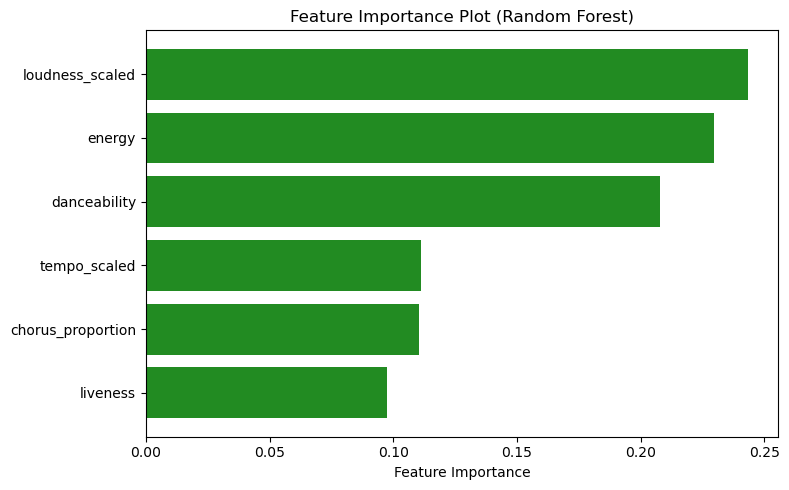

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# 1. Load data
df2 = pd.read_csv("dataset-of-10s.csv")

# 2. Recreate engineered features (run this once per session)
df2['loudness_scaled'] = (df2['loudness'] - df2['loudness'].mean()) / df2['loudness'].std()
df2['tempo_scaled'] = (df2['tempo'] - df2['tempo'].mean()) / df2['tempo'].std()
df2['chorus_proportion'] = df2['chorus_hit'] / df2['duration_ms']

# 3. Feature set and target
cols_of_interest = ['danceability', 'energy', 'liveness',
                    'loudness_scaled', 'tempo_scaled', 'chorus_proportion']

X = df2[cols_of_interest]
y = df2['target']

# 4. Fit Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=0
)
rf.fit(X, y)

# 5. Feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)

# 6. Plot
plt.figure(figsize=(8, 5))
plt.barh(range(len(cols_of_interest)), importances[indices], color='forestgreen')
plt.yticks(range(len(cols_of_interest)), np.array(cols_of_interest)[indices])
plt.xlabel("Feature Importance")
plt.title("Feature Importance Plot (Random Forest)")
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Number of songs')

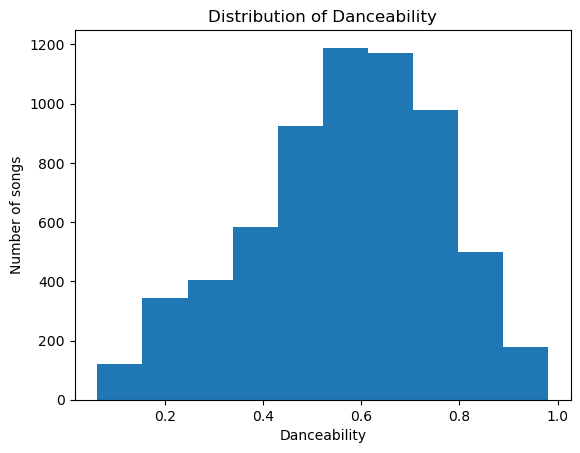

In [42]:
feature_names
X_train
#X_train['danceability'].hist()

plt.hist(df['danceability'])
plt.title("Distribution of Danceability")
plt.xlabel("Danceability")
plt.ylabel("Number of songs")

Text(0, 0.5, 'Number of songs')

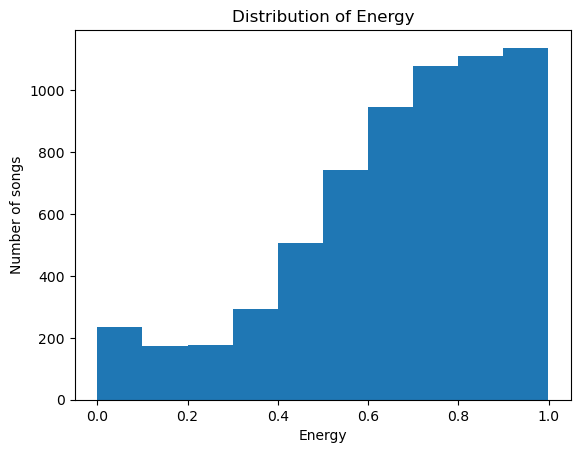

In [43]:

plt.hist(df['energy'])
plt.title("Distribution of Energy")
plt.xlabel("Energy")
plt.ylabel("Number of songs")

Text(0, 0.5, 'Number of songs')

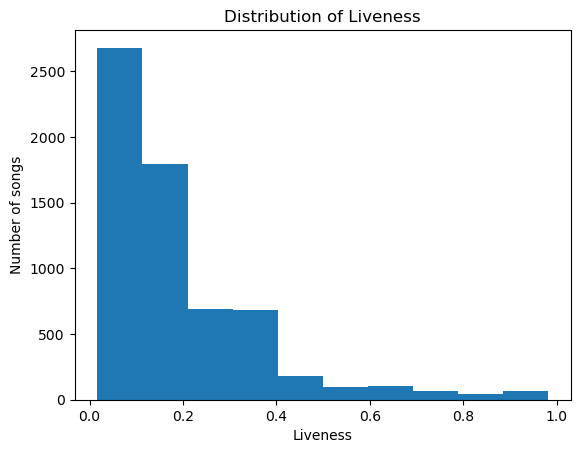

In [44]:
plt.hist(df['liveness'])
plt.title("Distribution of Liveness")
plt.xlabel("Liveness")
plt.ylabel("Number of songs")

Text(0, 0.5, 'Number of songs')

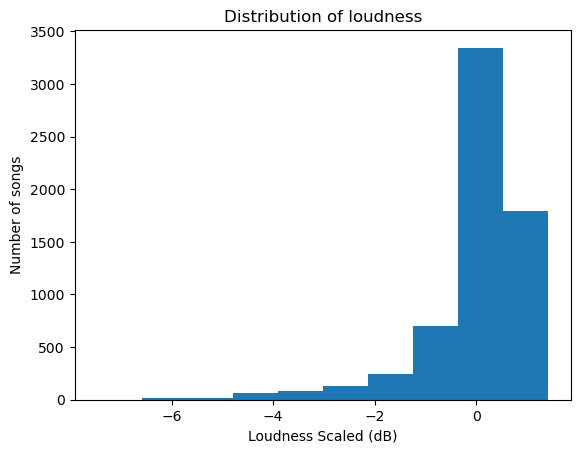

In [48]:
plt.hist(df['loudness_scaled'])
plt.title("Distribution of loudness")
plt.xlabel("Loudness Scaled (dB)")
plt.ylabel("Number of songs")

Text(0, 0.5, 'Number of songs')

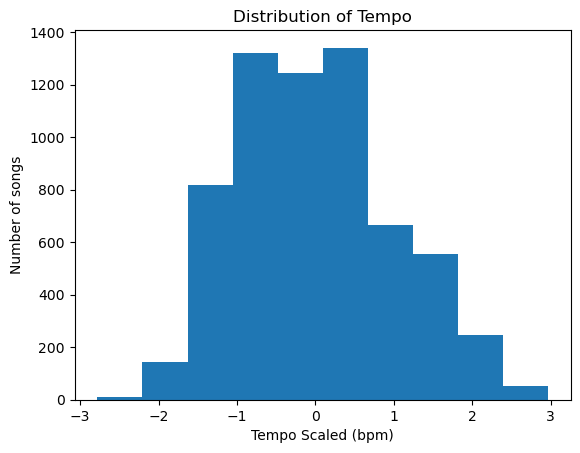

In [46]:
plt.hist(df['tempo_scaled'])
plt.title("Distribution of Tempo")
plt.xlabel("Tempo Scaled (bpm)")
plt.ylabel("Number of songs")

Text(0, 0.5, 'Number of songs')

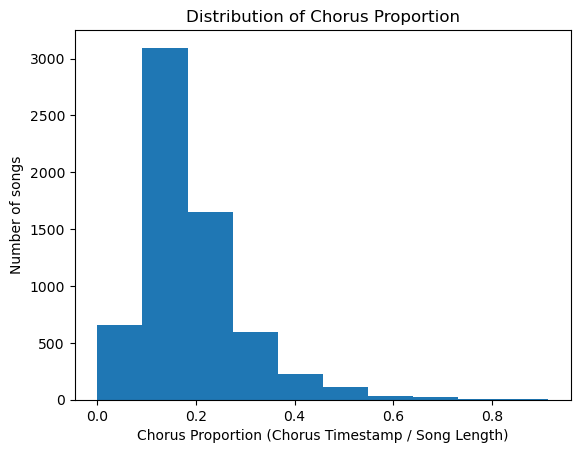

In [47]:
plt.hist(df['chorus_proportion'])
plt.title("Distribution of Chorus Proportion")
plt.xlabel("Chorus Proportion (Chorus Timestamp / Song Length)")
plt.ylabel("Number of songs")

In [24]:
permutation_importance(best_clf, X_valid, y_valid, scoring="accuracy", random_state=5)

{'importances_mean': array([0.0703125, 0.104375 , 0.006875 , 0.1478125, 0.015    , 0.0121875]),
 'importances_std': array([0.01218349, 0.00960143, 0.00253876, 0.01080726, 0.00775605,
        0.00526634]),
 'importances': array([[0.0671875, 0.071875 , 0.05     , 0.0875   , 0.075    ],
        [0.0953125, 0.1078125, 0.1046875, 0.1203125, 0.09375  ],
        [0.00625  , 0.0109375, 0.0078125, 0.003125 , 0.00625  ],
        [0.14375  , 0.1453125, 0.16875  , 0.14375  , 0.1375   ],
        [0.0265625, 0.0078125, 0.0078125, 0.021875 , 0.0109375],
        [0.0125   , 0.015625 , 0.0109375, 0.003125 , 0.01875  ]])}

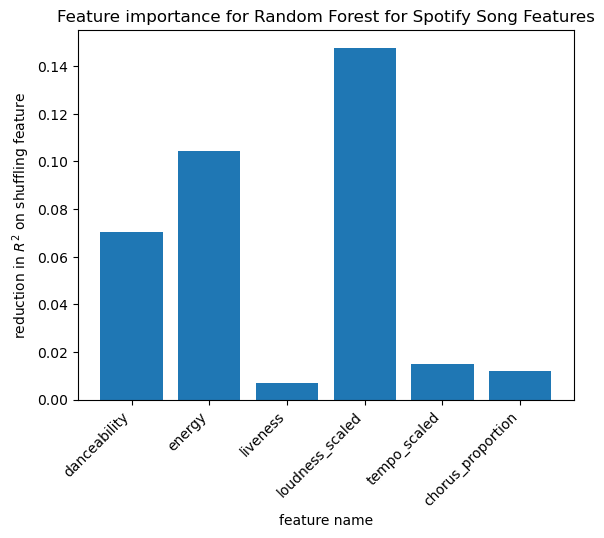

In [25]:
#testing feature importance using permutation_importance on validation data
#method taken from 05featureEngineering.pdf handout
pi = permutation_importance(best_clf, X_valid, y_valid, scoring="accuracy", random_state=5)#deterministic

plt.bar(x=range(X.columns.size), height=pi.importances_mean, tick_label=X.columns)
plt.title('Feature importance for Random Forest for Spotify Song Features')
plt.xlabel('feature name')
plt.xticks(rotation=45, ha='right')
_ = plt.ylabel(r'reduction in $R^2$ on shuffling feature')

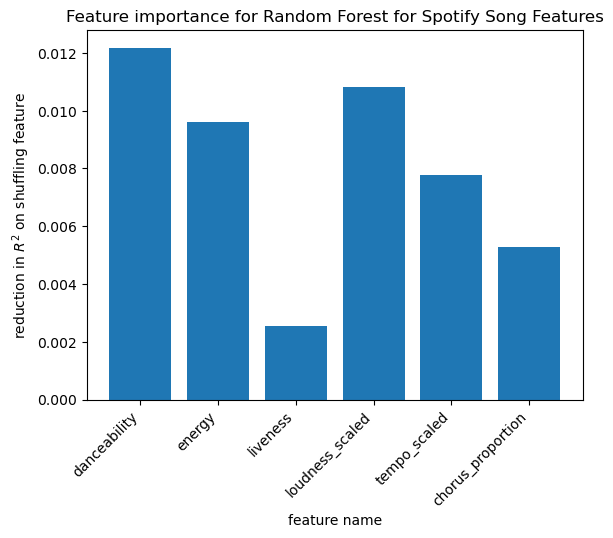

In [26]:
plt.bar(x=range(X.columns.size), height=pi.importances_std, tick_label=X.columns)
plt.title('Feature importance for Random Forest for Spotify Song Features')
plt.xlabel('feature name')
plt.xticks(rotation=45, ha='right')
_ = plt.ylabel(r'reduction in $R^2$ on shuffling feature')

using importances_mean, 'energy' (mean = 0.111875) and 'loudness_scaled'(mean = 0.1428125) are most important features...I think

# Evaluation

In [27]:
#the result of calling .score(X_test, y_test) on your best classifier/hyperparameters
print(f"The test accuracy for the best classifier/hyperparameters (random forest) is: {best_clf.score(X_test, y_test)}")

The test accuracy for the best classifier/hyperparameters (random forest) is: 0.790625


## ROC 

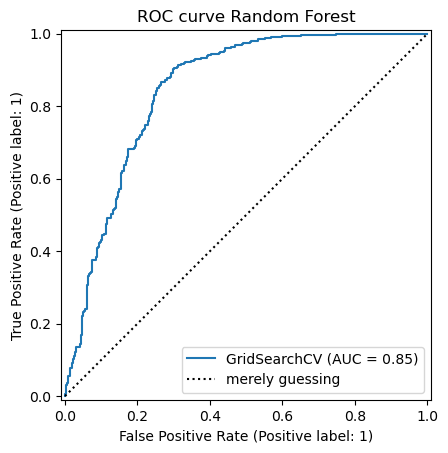

In [28]:
#ROC curve of Random Forest Classifier (best_clf)
RocCurveDisplay.from_estimator(best_clf, X_test, y_test)
plt.plot([0, 1], [0, 1], ':k', label='merely guessing') # add diagonal line
plt.title('ROC curve Random Forest')
_ = plt.legend()

In [29]:
1-((280)/(231+89+40+280))

0.5625

## Create confusion matrix of Random Forest Model (Tell something about the errors)

In [30]:
#Show a confusion matrix from the true y_test values and the corresponding  𝑦̂ values predicted by your best classifier/hyperparameters on X_test.
#referenced in-class notes

#assigning y_hat to be the predicted outcome (1, 0 in target col - flop/not) using the best model (random forest model)
y_hat = best_clf.predict(X_test)
M = confusion_matrix(y_true=y_test, y_pred=y_hat)


# Labels for binary classes
row_labels = ['actual 0', 'actual 1']
col_labels = ['predict 0', 'predict 1']


df1 = pd.DataFrame(M, index=row_labels, columns=col_labels)

print("confusion matrix:\n", df1)

#for each wrong prediction...
#Show The index  𝑖 in the test data of that example  𝐱
incorrect_prediction = np.where(y_hat != y_test)[0]


for i in incorrect_prediction:
    true_label = y_test.iloc[i]
    pred_label = y_hat[i]

confusion matrix:
           predict 0  predict 1
actual 0        240         80
actual 1         54        266


## Metrics (precision, recall, f1-score) based on Random Forest Model

In [31]:
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.82      0.75      0.78       320
           1       0.77      0.83      0.80       320

    accuracy                           0.79       640
   macro avg       0.79      0.79      0.79       640
weighted avg       0.79      0.79      0.79       640



## Helpful Graphs and Data Visualizations

graph particular variables of interest (like dancibility)...etc. 